In [ ]:
# %% [markdown]
# ### Dynamic Delisted Ticker Pruning Pipeline
# Identifies and removes dead/delisted CSV files based on temporal clustering
# (Infimum of active batch) and prunes the latest master ticker CSV.

# %%
import csv
from datetime import datetime, timedelta
import os
from pathlib import Path
import re
import shutil

# ==============================================================================
# PIPELINE CONFIGURATION
# ==============================================================================
BASE_DIR = Path(r"C:\Users\ping\Desktop\yloader")
TICKERS_DIR = BASE_DIR / "tickers"
QUARANTINE_DIR = BASE_DIR / "_quarantine_delisted"

SIZE_THRESHOLD_BYTES = 2048  # 2 KB delisted threshold
GAP_HOURS_THRESHOLD = 18.0  # Temporal discontinuity threshold to separate batches
MAX_PURGE_RATIO = 0.05  # Fail-safe: halt if > 5% of universe flagged

# Safety switch: Set to False to execute quarantine and rewrite master ticker list
DRY_RUN = True
# DRY_RUN = False

# %% [markdown]
# ### Step 1: Universe Scan & Temporal Cluster Analysis
# Resolves $T_{\text{cutoff}} = \inf(\text{Active Batch Cluster})$ via backward gap walk.

# %%
if not BASE_DIR.is_dir():
    raise FileNotFoundError(f"Target directory does not exist: {BASE_DIR}")

# Scan direct CSV files in yloader (ignoring subdirectories like temp/ or tickers/)
file_stats = []
for p in BASE_DIR.glob("*.csv"):
    if p.is_file():
        stat = p.stat()
        file_stats.append(
            {
                "ticker": p.stem.upper(),
                "path": p,
                "mtime": stat.st_mtime,
                "dt": datetime.fromtimestamp(stat.st_mtime),
                "size": stat.st_size,
            }
        )

universe_size = len(file_stats)
if universe_size == 0:
    raise RuntimeError(f"No CSV files found directly in {BASE_DIR}")

# Sort descending by mtime (newest -> oldest)
file_stats.sort(key=lambda x: x["mtime"], reverse=True)

# Algorithmic Infimum Resolution: Walk backward from T_max to locate the quiet gap
t_max_dt = file_stats[0]["dt"]
t_cutoff = None
t_cutoff_dt = None

for i in range(len(file_stats) - 1):
    curr_time = file_stats[i]["mtime"]
    prev_time = file_stats[i + 1]["mtime"]
    gap_hours = (curr_time - prev_time) / 3600.0

    if gap_hours >= GAP_HOURS_THRESHOLD:
        # The infimum (earliest file of the active cluster) is curr_time
        t_cutoff = curr_time
        t_cutoff_dt = file_stats[i]["dt"]
        break

if t_cutoff is None:
    # No discontinuous cluster found; all files belong to a single contiguous batch
    t_cutoff = file_stats[-1]["mtime"]
    t_cutoff_dt = file_stats[-1]["dt"]

print("=" * 70)
print(f"Total Universe CSV Count : {universe_size}")
print(f"Latest Active File (T_max): {t_max_dt.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Infimum Cutoff (T_cutoff): {t_cutoff_dt.strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 70)

# %% [markdown]
# ### Step 2: Content Audit & Outlier Candidate Isolation
# Flags files strictly satisfying: `mtime < T_cutoff` AND `size <= 2 KB`.

# %%
delisted_candidates = []

for record in file_stats:
    is_older_than_cutoff = record["mtime"] < t_cutoff
    is_under_size = record["size"] <= SIZE_THRESHOLD_BYTES

    if is_older_than_cutoff and is_under_size:
        # Ground-truth content inspection: count data lines
        line_count = 0
        preview = ""
        try:
            with open(record["path"], "r", encoding="utf-8", errors="ignore") as f:
                for idx, line in enumerate(f):
                    line_count += 1
                    if idx == 0:
                        preview = line.strip()[:40]
                    if line_count > 5:
                        break
        except Exception as e:
            preview = f"ERROR_READING: {e}"

        record["lines"] = line_count
        record["preview"] = preview
        delisted_candidates.append(record)

# Fail-safe assertions
purge_ratio = len(delisted_candidates) / universe_size
if purge_ratio > MAX_PURGE_RATIO:
    raise RuntimeError(
        f"ABORTED: Flagged {len(delisted_candidates)} files ({purge_ratio:.1%}). "
        f"Exceeds fail-safe threshold of {MAX_PURGE_RATIO:.1%}."
    )

print(f"Identified Delisted Candidates: {len(delisted_candidates)}")
print(
    f"{'Ticker':<10} {'Size (Bytes)':<14} {'Modified':<22} {'Lines':<8} {'Header Preview'}"
)
print("-" * 70)
for c in delisted_candidates:
    print(
        f"{c['ticker']:<10} {c['size']:<14} {c['dt'].strftime('%Y-%m-%d %H:%M:%S'):<22} {c['lines']:<8} {c['preview']}"
    )
print("-" * 70)

delisted_symbols = {c["ticker"] for c in delisted_candidates}

# %% [markdown]
# ### Step 3: Task 1 Execution - Quarantine Delisted CSVs
# Moves files to `_quarantine_delisted/` rather than unrecoverable deletion.

# %%
if not DRY_RUN and delisted_candidates:
    QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)
    moved_count = 0
    for c in delisted_candidates:
        src = c["path"]
        dst = QUARANTINE_DIR / src.name
        shutil.move(src, dst)
        moved_count += 1
    print(f"Task 1 Complete: {moved_count} CSV files moved to {QUARANTINE_DIR}")
elif DRY_RUN:
    print(
        f"[DRY_RUN Active] Task 1 skipped: {len(delisted_candidates)} files staged for quarantine."
    )

# %% [markdown]
# ### Step 4: Task 2 Execution - Dynamic Master Ticker Pruning
# Dynamically resolves newest `YYYY-MM-DD_tickers.csv`, backs it up, and atomically writes the pruned universe.

# %%
# Locate all candidate ticker files matching YYYY-MM-DD_tickers.csv
ticker_files = list(TICKERS_DIR.glob("*_tickers.csv"))
date_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2})_tickers\.csv$")

valid_ticker_files = []
for tf in ticker_files:
    match = date_pattern.match(tf.name)
    if match:
        try:
            file_date = datetime.strptime(match.group(1), "%Y-%m-%d").date()
            valid_ticker_files.append((file_date, tf))
        except ValueError:
            continue

if not valid_ticker_files:
    raise FileNotFoundError(f"No valid YYYY-MM-DD_tickers.csv found in {TICKERS_DIR}")

# Select the newest master ticker file
valid_ticker_files.sort(key=lambda x: x[0], reverse=True)
target_ticker_file = valid_ticker_files[0][1]
print(f"Target Master Ticker File : {target_ticker_file.name}")

# Read raw ticker list (preserving exact order; handles headerless files where cell A1 is 'A')
raw_tickers = []
with open(target_ticker_file, "r", encoding="utf-8-sig") as f:
    reader = csv.reader(f)
    for row in reader:
        if row and row[0].strip():
            raw_tickers.append(row[0].strip().upper())

initial_count = len(raw_tickers)
pruned_tickers = [t for t in raw_tickers if t not in delisted_symbols]
dropped_count = initial_count - len(pruned_tickers)

print(f"Master List Initial Count: {initial_count}")
print(f"Delisted Tickers Removed : {dropped_count}")
print(f"Cleaned Universe Count   : {len(pruned_tickers)}")

# Fail-safe check against Excel file-locking
if not DRY_RUN:
    backup_file = target_ticker_file.with_suffix(".csv.bak")
    shutil.copy2(target_ticker_file, backup_file)
    print(f"Backup created at         : {backup_file.name}")

    temp_file = target_ticker_file.with_suffix(".tmp")
    try:
        with open(temp_file, "w", encoding="utf-8", newline="") as f:
            writer = csv.writer(f)
            for ticker in pruned_tickers:
                writer.writerow([ticker])

        # Atomic replace (guarantees no corrupted writes)
        temp_file.replace(target_ticker_file)
        print("Task 2 Complete: Master ticker file updated successfully.")
    except PermissionError:
        if temp_file.exists():
            temp_file.unlink()
        raise PermissionError(
            f"Lock Error: Cannot write to {target_ticker_file.name}. "
            "Close Excel if the file is currently open and re-run."
        )
else:
    print(
        f"[DRY_RUN Active] Task 2 skipped: Would remove {dropped_count} tickers from {target_ticker_file.name}."
    )
    print("\nTo apply changes, set DRY_RUN = False in Step 1 and execute.")

Total Universe CSV Count : 1725
Latest Active File (T_max): 2026-09-27 07:35:09
Infimum Cutoff (T_cutoff): 2026-09-27 07:23:29
Identified Delisted Candidates: 9
Ticker     Size (Bytes)   Modified               Lines    Header Preview
----------------------------------------------------------------------
WBS        45             2026-09-24 02:09:31    1        2026-08-19,78.03,78.135,77.5,77.57,91306
NUVL       48             2026-09-24 02:06:58    1        2026-07-14,123.96,123.99,123.95,123.96,3
MVO        43             2026-09-24 02:06:38    1        2026-07-24,0.64,0.66,0.5823,0.5955,65880
LEG        1139           2026-09-24 02:05:43    6        2026-07-17,11.15,11.38,10.93,11.03,15725
LBRDK      38             2026-09-24 02:05:42    1        2026-08-19,35.01,37.59,35.01,36.02,0
EQR        42             2026-09-24 02:03:28    1        2026-08-17,65.96,66.1,63.3,63.66,7449691
EA         47             2026-09-24 02:03:15    1        2026-08-04,209.91,209.98,209.7,209.7,484
AXIA  

Directory: C:\Users\ping\Desktop\yloader
Total CSV Files: 1725
      date  file_count    min_kb  median_kb     max_kb
2026-09-24           9  0.037109   0.043945   1.760742
2026-09-26        1641  4.072266 260.303711 398.159180
2026-09-27          75 18.411133 272.961914 385.590820


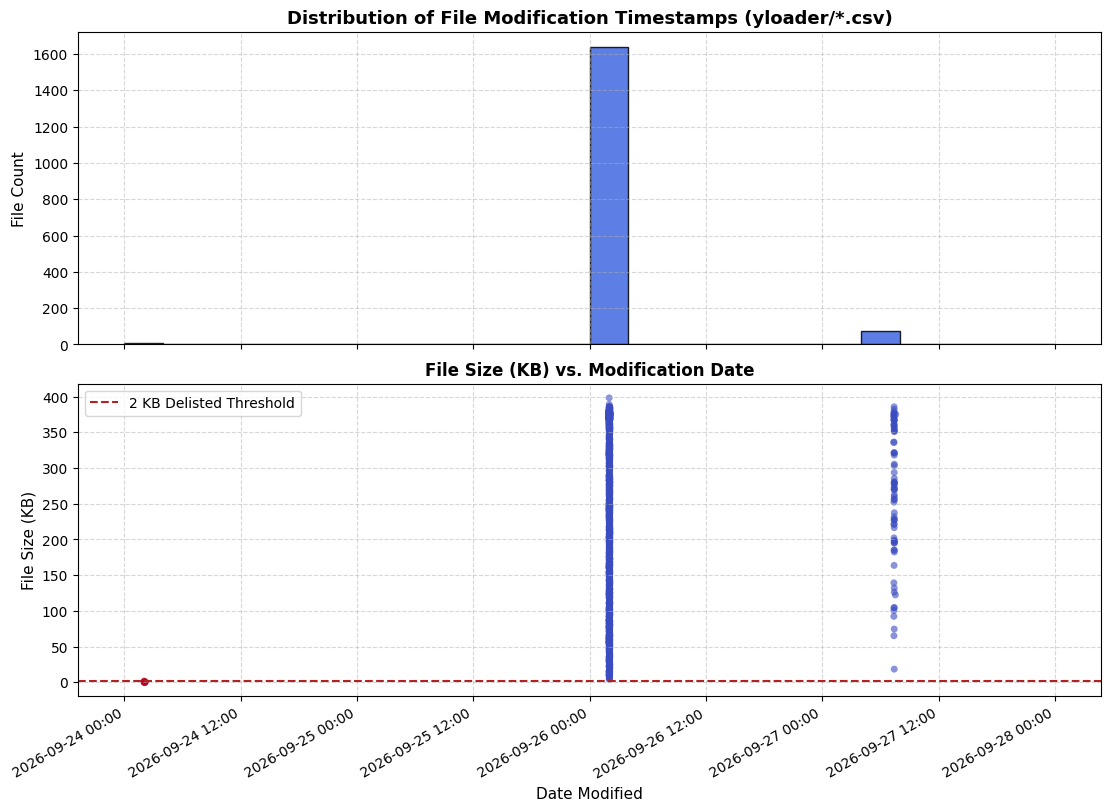

In [2]:
# %% [markdown]
# ### File Date Distribution & Cluster Analysis
# Analyzes `mtime` distribution and file sizes in `C:\Users\ping\Desktop\yloader`
# to visually isolate stale/delisted clusters from the current batch.

# %%
import os
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

# Target directory
TARGET_DIR = Path(r"C:\Users\ping\Desktop\yloader")

# 1. Harvest file metadata (skip subdirectories)
records = []
for p in TARGET_DIR.glob("*.csv"):
    if p.is_file():
        stat = p.stat()
        mtime_dt = datetime.fromtimestamp(stat.st_mtime)
        records.append(
            {
                "ticker": p.stem,
                "file_name": p.name,
                "mtime": mtime_dt,
                "date": mtime_dt.date(),
                "size_kb": stat.st_size / 1024.0,
            }
        )

df = pd.DataFrame(records)

# Pre-flight trap
if df.empty:
    raise FileNotFoundError(f"No CSV files found directly inside {TARGET_DIR}")

# %% [markdown]
# ### Console Summary Audit
# Group by modified date and compute size metrics to verify batch separation.

# %%
summary = (
    df.groupby("date")
    .agg(
        file_count=("ticker", "count"),
        min_kb=("size_kb", "min"),
        median_kb=("size_kb", "median"),
        max_kb=("size_kb", "max"),
    )
    .reset_index()
)

print("=" * 60)
print(f"Directory: {TARGET_DIR}")
print(f"Total CSV Files: {len(df)}")
print("=" * 60)
print(summary.to_string(index=False))
print("=" * 60)

# %% [markdown]
# ### Visual Histogram: Modification Dates & Size Clustering

# %%
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(11, 8), sharex=True, constrained_layout=True
)

# Plot 1: Histogram of file counts over time
date_counts = df["mtime"].dt.floor("h")  # Hourly resolution bins
bins = pd.date_range(
    start=date_counts.min().floor("D"),
    end=date_counts.max().ceil("D"),
    freq="4h",
)

ax1.hist(df["mtime"], bins=bins, color="royalblue", edgecolor="black", alpha=0.85)
ax1.set_title(
    "Distribution of File Modification Timestamps (yloader/*.csv)",
    fontsize=13,
    fontweight="bold",
)
ax1.set_ylabel("File Count", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Scatter plot of Date vs File Size (isolates the <= 2KB cluster)
scatter = ax2.scatter(
    df["mtime"],
    df["size_kb"],
    c=(df["size_kb"] <= 2.0),
    cmap="coolwarm",  # Red for <= 2KB, Blue for normal files
    alpha=0.6,
    edgecolors="none",
    s=25,
)
ax2.axhline(
    2.0,
    color="firebrick",
    linestyle="--",
    linewidth=1.5,
    label="2 KB Delisted Threshold",
)
ax2.set_title("File Size (KB) vs. Modification Date", fontsize=12, fontweight="bold")
ax2.set_ylabel("File Size (KB)", fontsize=11)
ax2.set_xlabel("Date Modified", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

# Format X-axis dates
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.xticks(rotation=30, ha="right")

plt.show()